# ACO / ACO + refinement / KMeans comparison with the new optimizer architecture

This notebook tests the new refactor:

- `AntClusteringOptimizer` is the shared optimization engine.
- `construct_aco_solution` and `construct_aco_refinement_solution` are the only algorithm-specific construction strategies.
- `fitness_weighted_sum` is shared.
- `update_pheromone_all_ants` / `update_pheromone_best_ant` are shared pheromone update functions.
- preprocessing and plotting are reused from the shared modules.

The goal is to compare ACO variants while keeping fitness, pheromone update, preprocessing, and plotting consistent.


In [28]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [103]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from moduli.preprocessing import (
    build_raw_features,
    build_koppen_features,
    build_temp_rain_pca_features,
    prepare_model_data,
)

from moduli.ant_clustering_optimizer import AntClusteringOptimizer
from moduli.construction_strategies import (
    construct_aco_solution,
    construct_aco_refinement_solution,
    construct_graph_aco_solution,
    construct_multicolony_solution
)
from moduli.heuristics import (
    centroid_heuristic,
    graph_heuristic,
    spatial_heuristic,
    graph_cohesion_heuristic
)
from moduli.fitness_functions import (
    fitness_weighted_sum,
    silhouette_spatial_fitness,
    snn_spatial_fitness,
)
from moduli.snn_graph import build_snn_graph
from moduli.pheromone_updates import (
    initialize_node_cluster_pheromone,
    update_pheromone_all_ants,
    update_pheromone_best_ant,
    update_pheromone_quality_weighted,
)
from moduli.plot_utils import plot_cluster_comparison, plot_single_cluster_map


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
from moduli.vegetation_eval import (
    load_clc_legend,
    evaluate_label_set,
)

VEGETATION_PATH = "../../vegetacija.csv"
CLC_LEGEND_PATH = "../../Vegetacija/u2018_clc2018_v2020_20u1_raster100m/Legend/CLC2018_CLC2018_V2018_20_QGIS.txt"

vegetation = pd.read_csv(VEGETATION_PATH)
legend = load_clc_legend(CLC_LEGEND_PATH)

## Configuration

Change these values to compare pixel/superpixel mode and feature representations.


In [30]:
DATA_PATH = "../../df_valid.csv"

# "superpixels" or "pixels"
MODE = "superpixels"

# "koppen", "raw", or "pca_before_superpixels"
FEATURE_MODE = "koppen"

N_CLUSTERS = 5
TARGET_SIZE = 150
K_NEIGHBORS = 16
RANDOM_STATE = 0


## Load data and build features

Feature construction is separate from preprocessing, so the same optimizer setup can be tested with raw, Köppen-like, or PCA features.


In [31]:
df = pd.read_csv(DATA_PATH, index_col=0)

if FEATURE_MODE == "koppen":
    X_features, feature_names = build_koppen_features(df)

elif FEATURE_MODE == "raw":
    X_features, feature_names = build_raw_features(df)

elif FEATURE_MODE == "pca_before_superpixels":
    raw_X, feature_cols = build_raw_features(df)
    temp_cols = [c for c in feature_cols if "temp" in c.lower()]
    rain_cols = [c for c in feature_cols if "padavine" in c.lower()]

    X_features, feature_names, pca_info = build_temp_rain_pca_features(
        df,
        temp_cols=temp_cols,
        rain_cols=rain_cols,
        n_temp=2,
        n_rain=2,
        final_scale=True,
    )

    print("Temperature explained variance:")
    print(pca_info["temp_explained_variance"])
    print("Rainfall explained variance:")
    print(pca_info["rain_explained_variance"])

else:
    raise ValueError("FEATURE_MODE must be 'koppen', 'raw', or 'pca_before_superpixels'.")

print("df shape:", df.shape)
print("X_features shape:", X_features.shape)
print("feature_names:", feature_names)


df shape: (301394, 35)
X_features shape: (301394, 9)
feature_names: ['temp_mean', 'temp_min', 'temp_max', 'temp_range', 'precip_mean', 'precip_min', 'precip_max', 'precip_total', 'precip_range']


## Prepare model data

This creates the common model inputs:

```python
X
neighbors
weights
```

Both ACO variants receive exactly the same inputs.


In [32]:
data = prepare_model_data(
    df=df,
    X_features=X_features,
    feature_names=feature_names,
    mode=MODE,
    target_size=TARGET_SIZE,
    k_neighbors=K_NEIGHBORS,
    scale_final=True,
    random_state=RANDOM_STATE,
)

X = data["X_model"]
neighbors = data["neighbors"]
weights = data["weights"]

df_model = data["df"]
node_col = data["node_col"]

print("mode:", data["mode"])
print("node_col:", node_col)
print("X shape:", X.shape)
print("neighbors shape:", neighbors.shape)
print("weights shape:", weights.shape)


mode: superpixels
node_col: superpixel_compact
X shape: (2009, 9)
neighbors shape: (2009, 16)
weights shape: (2009,)


In [175]:
snn_graph = build_snn_graph(
    X=X,
    k=50,
    min_shared_neighbors=1,
    spatial_neighbors=neighbors,
)

print("SNN graph shape:", snn_graph.shape)
print("SNN graph edges:", snn_graph.nnz // 2)

SNN graph shape: (2009, 2009)
SNN graph edges: 13153


## Shared optimizer settings

Fitness settings are split so the centroid-based and silhouette-based objectives can be swapped in AntClusteringOptimizer without changing the optimizer loop.

ACO below uses silhouette_spatial_fitness; the KMeans baseline keeps the centroid-based objective for comparison.

In [105]:
CENTROID_FITNESS_KWARGS = {
    "w_compactness": 0.7,
}

In [106]:
SILHOUETTE_FITNESS_KWARGS = {
    "w_silhouette": 0.7,
    "use_full_dataset": True,
    "sample_size": 500,
    "min_same_cluster_sample": 1,
    "full_cluster_fallback": True,
}

In [176]:
SNN_FITNESS_KWARGS = {
    "w_snn": 0.7,
    "snn_graph": snn_graph,
}

In [108]:
COMMON_FITNESS_KWARGS = {
    "w_spatial": 0.3,
    "spatial_symmetric": False,
}

COMMON_PHEROMONE_INIT_KWARGS = {
    "initial_value": 1.0,
    "normalize_rows": True,
}

COMMON_PHEROMONE_UPDATE_KWARGS = {
    "clip_min": 1e-6,
    "clip_max": 1e6,
    "normalize_rows": True,
}

## KMeans baseline

KMeans is fitted on the same `X`.

Its centroids are used as optional base centroids for ACO + refinement construction.


In [52]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    random_state=RANDOM_STATE,
).fit(X)

base_centroids = kmeans.cluster_centers_

kmeans_centroid_fitness, kmeans_centroid_terms = fitness_weighted_sum(
    X=X,
    labels=kmeans.labels_,
    centroids=base_centroids,
    weights=weights,
    neighbors=neighbors,
    **CENTROID_FITNESS_KWARGS,
    **COMMON_FITNESS_KWARGS,
)

print(f"Centroid")
print(kmeans_centroid_fitness)
print(kmeans_centroid_terms)

kmeans_sil_fitness, kmeans_sil_terms = silhouette_spatial_fitness(
    X=X,
    labels=kmeans.labels_,
    centroids=base_centroids,
    weights=weights,
    neighbors=neighbors,
    **SILHOUETTE_FITNESS_KWARGS,
    **COMMON_FITNESS_KWARGS,
)

print(f"\nSilhouette")
print(kmeans_sil_fitness)
print(kmeans_sil_terms)

Centroid
0.2376042185340272
{'compactness': 0.19379977603275308, 'spatial': 0.3398145843703335}

Silhouette
0.3317335099032432
{'silhouette': 0.34345961545101955, 'silhouette_term': 0.3282701922744902, 'silhouette_sample_size': 2009, 'silhouette_n_evaluated': 2009, 'silhouette_fallback_count': 0, 'silhouette_skipped_count': 0, 'silhouette_full_dataset': True, 'spatial': 0.3398145843703335}


In [18]:
koppen_labels = pd.read_csv("../../koppen_labels_aggregated.csv", index_col=0)
koppen_labels

,0
0,1
1,1
2,3
3,3
4,1
...,...
2004,1
2005,1
2006,3
2007,1


## ACO via `AntClusteringOptimizer`

ACO-specific behavior is only in `construct_aco_solution`.


In [177]:
# Choose one:
# ACO_PHEROMONE_UPDATE_FN = update_pheromone_all_ants
ACO_PHEROMONE_UPDATE_FN = update_pheromone_best_ant 
# ACO_PHEROMONE_UPDATE_FN = update_pheromone_quality_weighted

aco = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_aco_solution,
    construct_kwargs={
        "alpha": 1,
        "beta_feature": 3,
        "centroid": False
    },

    fitness_fn=snn_spatial_fitness,
    fitness_kwargs={
        **SNN_FITNESS_KWARGS,
        **COMMON_FITNESS_KWARGS,
    },

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=ACO_PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.1,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=None
)

aco.fit(X, neighbors, weights=weights)


Iter 1/20 | iter_best=0.6601 | iter_mean=0.7278 | iter_std=0.0342 | global_best=0.6601 | snn_cut=0.6503 | internal_snn=2103.9400 | external_snn=3912.6400 | total_snn=6016.5800 | snn_edges=13153.0000 | spatial=0.6830 | pheromone_min=1.8447e-01 | pheromone_max=2.6210e-01
Iter 2/20 | iter_best=0.6460 | iter_mean=0.7294 | iter_std=0.0426 | global_best=0.6460 | snn_cut=0.6346 | internal_snn=2198.7000 | external_snn=3817.8800 | total_snn=6016.5800 | snn_edges=13153.0000 | spatial=0.6726 | pheromone_min=1.6987e-01 | pheromone_max=3.2054e-01
Iter 3/20 | iter_best=0.5636 | iter_mean=0.6629 | iter_std=0.0588 | global_best=0.5636 | snn_cut=0.5447 | internal_snn=2739.1600 | external_snn=3277.4200 | total_snn=6016.5800 | snn_edges=13153.0000 | spatial=0.6075 | pheromone_min=1.5462e-01 | pheromone_max=3.8151e-01
Iter 4/20 | iter_best=0.5205 | iter_mean=0.5958 | iter_std=0.0469 | global_best=0.5205 | snn_cut=0.4998 | internal_snn=3009.6000 | external_snn=3006.9800 | total_snn=6016.5800 | snn_edges=13

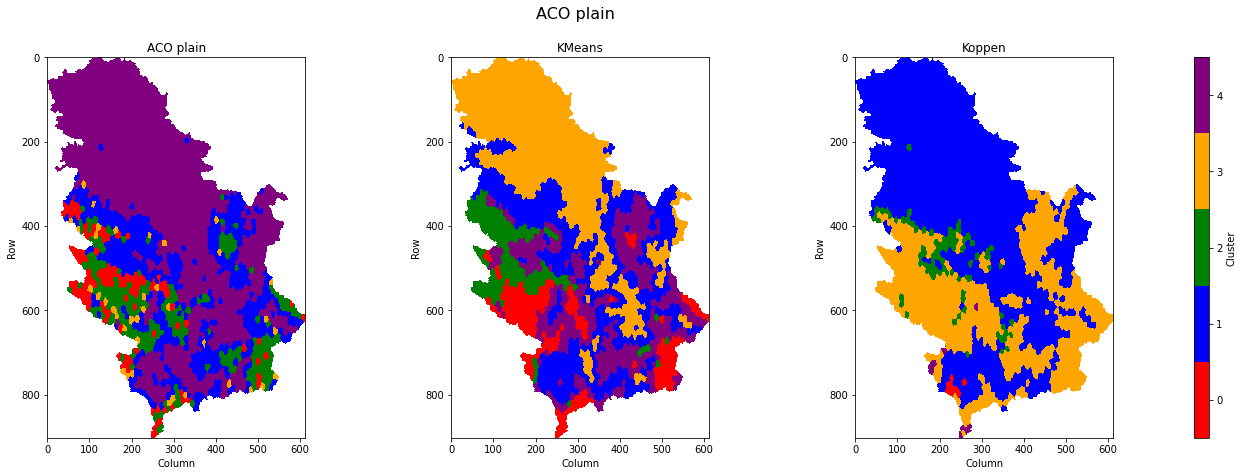

0.30847312178491926
{'compactness': 0.3065606568057333, 'spatial': 0.31293554006968644}
ARI ACO vs KMeans: 0.45630212640441076
ARI Koppen vs ACO: 0.5178557761428583
0.4444724831821172


In [132]:
plot_cluster_comparison(
    df=df_model,
    label_dict={
        "ACO plain": aco.labels_,
        "KMeans": kmeans.labels_,
        "Koppen": koppen_labels["0"],
    },
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"ACO plain",
)

aco_centroid_fitness, aco_centroid_terms = fitness_weighted_sum(
    X=X,
    labels=aco.labels_,
    centroids=aco.centroids_,
    weights=weights,
    neighbors=neighbors,
    **CENTROID_FITNESS_KWARGS,
    **COMMON_FITNESS_KWARGS,
)
print(aco_centroid_fitness)
print(aco_centroid_terms)
print("ARI ACO vs KMeans:", adjusted_rand_score(aco.labels_, kmeans.labels_))
print("ARI Koppen vs ACO:", adjusted_rand_score(aco.labels_, koppen_labels["0"]))

overall_aco, per_cluster_aco, merged_aco = evaluate_label_set(
    method_name="ACO",
    labels=aco.labels_,
    data_df=df_model,
    node_col=node_col,
    vegetation=vegetation,
    legend=legend,
)

print(overall_aco["weighted_combined_ecological_consistency"])

## ACO + refinement via `AntClusteringOptimizer`

ACO + refinement-specific behavior is only in `construct_aco_refinement_solution`.


In [137]:
# Choose one:
ACO_REFINEMENT_PHEROMONE_UPDATE_FN = update_pheromone_all_ants
# ACO_REFINEMENT_PHEROMONE_UPDATE_FN = update_pheromone_best_ant
# ACO_REFINEMENT_PHEROMONE_UPDATE_FN = update_pheromone_quality_weighted

aco_refinement = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_aco_refinement_solution,
    construct_kwargs={
        "alpha": 1,
        "beta_feature": 3,
        "refinement_steps": 3,
        "centroid": True
    },

    fitness_fn=snn_spatial_fitness,
    fitness_kwargs={
        **SNN_FITNESS_KWARGS,
        **COMMON_FITNESS_KWARGS,
    },

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=ACO_REFINEMENT_PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.1,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=5
)

aco_refinement.fit(X, neighbors, weights=weights)


Iter 1/20 | iter_best=0.2824 | iter_mean=0.4754 | iter_std=0.1528 | global_best=0.2824 | snn_cut=0.2258 | internal_snn=3038.0000 | external_snn=886.1500 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.4145 | pheromone_min=4.5559e-02 | pheromone_max=7.9614e-01
Iter 2/20 | iter_best=0.2252 | iter_mean=0.2493 | iter_std=0.0174 | global_best=0.2252 | snn_cut=0.1653 | internal_snn=3275.3000 | external_snn=648.8500 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.3648 | pheromone_min=4.7931e-03 | pheromone_max=9.7855e-01
Iter 3/20 | iter_best=0.1633 | iter_mean=0.1794 | iter_std=0.0113 | global_best=0.1633 | snn_cut=0.1016 | internal_snn=3525.6000 | external_snn=398.5500 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.3072 | pheromone_min=2.8819e-04 | pheromone_max=9.9871e-01
Iter 4/20 | iter_best=0.1573 | iter_mean=0.1616 | iter_std=0.0025 | global_best=0.1573 | snn_cut=0.0946 | internal_snn=3552.8500 | external_snn=371.3000 | total_snn=3924.1500 | snn_edges=10050.

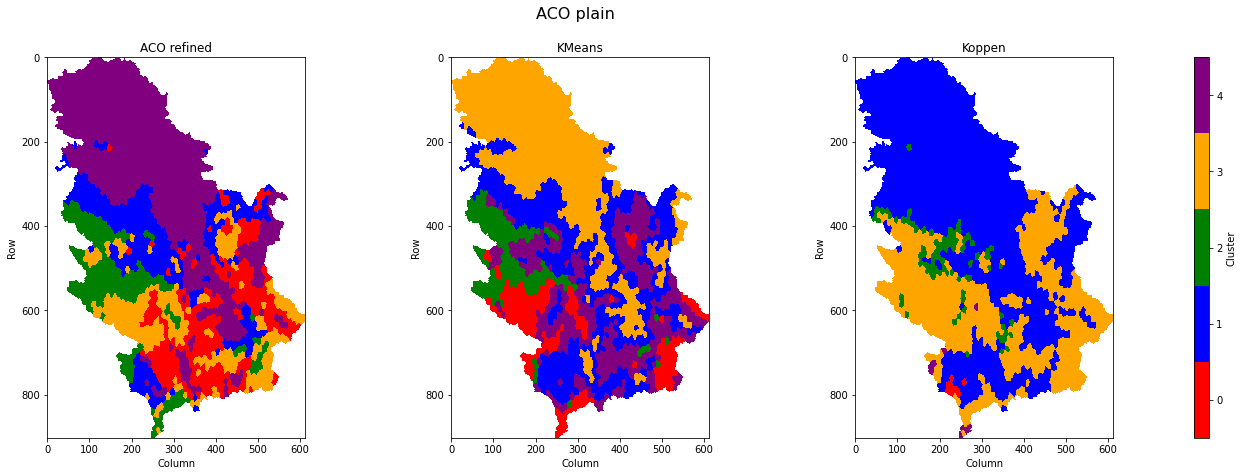

0.23652000313479438
{'compactness': 0.20882364097120237, 'spatial': 0.3011448481831757}
ARI ACO Refinement vs KMeans: 0.5504620674599251
ARI Koppen vs ACO: 0.4239055284833959
0.47117398678310535


In [138]:
plot_cluster_comparison(
    df=df_model,
    label_dict={
        "ACO refined": aco_refinement.labels_,
        "KMeans": kmeans.labels_,
        "Koppen": koppen_labels["0"],
    },
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"ACO plain",
)

aco_refinement_centroid_fitness, aco_refinement_centroid_terms = fitness_weighted_sum(
    X=X,
    labels=aco_refinement.labels_,
    centroids=aco_refinement.centroids_,
    weights=weights,
    neighbors=neighbors,
    **CENTROID_FITNESS_KWARGS,
    **COMMON_FITNESS_KWARGS,
)
print(aco_refinement_centroid_fitness)
print(aco_refinement_centroid_terms)
print("ARI ACO Refinement vs KMeans:", adjusted_rand_score(aco_refinement.labels_, kmeans.labels_))
print("ARI Koppen vs ACO:", adjusted_rand_score(aco_refinement.labels_, koppen_labels["0"]))

overall_aco_refinement, per_cluster_aco_refinement, merged_aco_refinement = evaluate_label_set(
    method_name="ACO + refinement",
    labels=aco_refinement.labels_,
    data_df=df_model,
    node_col=node_col,
    vegetation=vegetation,
    legend=legend,
)

print(overall_aco_refinement["weighted_combined_ecological_consistency"])

## Graph ACO via `AntClusteringOptimizer`

Graph ACO-specific behavior is only in `construct_graph_aco_solution`.


In [145]:
GRAPH_ACO_PHEROMONE_UPDATE_FN = update_pheromone_best_ant
graph_aco = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_graph_aco_solution,
    construct_kwargs={
        "alpha": 1,
        "beta_graph": 3,
    },

    fitness_fn=snn_spatial_fitness,
    fitness_kwargs={
        **SNN_FITNESS_KWARGS,
        **COMMON_FITNESS_KWARGS,
    },

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=GRAPH_ACO_PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.1,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=10
)

graph_aco.fit(X, neighbors, weights=weights)

Iter 1/20 | iter_best=0.3196 | iter_mean=0.3960 | iter_std=0.0436 | global_best=0.3196 | snn_cut=0.2668 | internal_snn=2877.1500 | external_snn=1047.0000 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.4427 | pheromone_min=1.4625e-01 | pheromone_max=4.1498e-01
Iter 2/20 | iter_best=0.3389 | iter_mean=0.3958 | iter_std=0.0414 | global_best=0.3196 | snn_cut=0.2907 | internal_snn=2783.4500 | external_snn=1140.7000 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.4515 | pheromone_min=1.0950e-01 | pheromone_max=5.6200e-01
Iter 3/20 | iter_best=0.2986 | iter_mean=0.4011 | iter_std=0.0688 | global_best=0.2986 | snn_cut=0.2440 | internal_snn=2966.6500 | external_snn=957.5000 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.4261 | pheromone_min=8.1451e-02 | pheromone_max=6.7420e-01
Iter 4/20 | iter_best=0.2904 | iter_mean=0.3823 | iter_std=0.0486 | global_best=0.2904 | snn_cut=0.2404 | internal_snn=2980.6000 | external_snn=943.5500 | total_snn=3924.1500 | snn_edges=1005

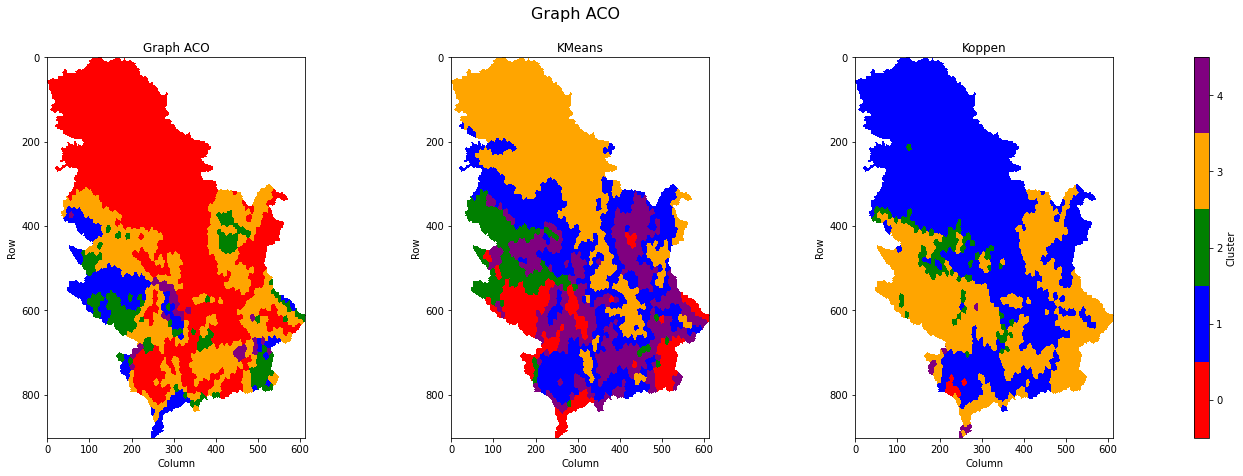

0.2929799742921728
{'compactness': 0.3027869361821625, 'spatial': 0.2700970632155301}
ARI Graph ACO vs KMeans: 0.45260405241830093
ARI Koppen vs Graph ACO: 0.5469359103356842
0.44563120999166994


In [146]:
plot_cluster_comparison(
    df=df_model,
    label_dict={
        "Graph ACO": graph_aco.labels_,
        "KMeans": kmeans.labels_,
        "Koppen": koppen_labels["0"],
    },
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"Graph ACO",
)

graph_aco_centroid_fitness, graph_aco_centroid_terms = fitness_weighted_sum(
    X=X,
    labels=graph_aco.labels_,
    centroids=graph_aco.centroids_,
    weights=weights,
    neighbors=neighbors,
    **CENTROID_FITNESS_KWARGS,
    **COMMON_FITNESS_KWARGS,
)
print(graph_aco_centroid_fitness)
print(graph_aco_centroid_terms)
print("ARI Graph ACO vs KMeans:", adjusted_rand_score(graph_aco.labels_, kmeans.labels_))
print("ARI Koppen vs Graph ACO:", adjusted_rand_score(graph_aco.labels_, koppen_labels["0"]))

overall_graph_aco, per_cluster_graph_aco, merged_graph_aco = evaluate_label_set(
    method_name="ACO + refinement",
    labels=graph_aco.labels_,
    data_df=df_model,
    node_col=node_col,
    vegetation=vegetation,
    legend=legend,
)

print(overall_graph_aco["weighted_combined_ecological_consistency"])

In [172]:
MULTI_ACO_PHEROMONE_UPDATE_FN = update_pheromone_all_ants
colonies = [
    # {
    #     "name": "centroid",
    #     "fn": centroid_heuristic,
    #     "params": {
    #         "beta_feature": 1,
    #     },
    # },
    {
        "name": "cohesion",
        "fn": graph_cohesion_heuristic,
        "params": {
            "beta_graph": 3,
        },
    },
    {
        "name": "graph",
        "fn": graph_heuristic,
        "params": {
            "beta_graph": 3,
        },
    },
    {
        "name": "spatial",
        "fn": spatial_heuristic,
        "params": {
            "beta_spatial": 1,
        },
    },
]
multi_type_aco = AntClusteringOptimizer(
    n_clusters=N_CLUSTERS,
    n_ants=15,
    n_iterations=20,

    construct_solution_fn=construct_multicolony_solution,
    construct_kwargs={
        "colony_heuristics": colonies,
        "alpha": 1,
    },

    fitness_fn=snn_spatial_fitness,
    fitness_kwargs={
        **SNN_FITNESS_KWARGS,
        **COMMON_FITNESS_KWARGS,
    },

    pheromone_init_fn=initialize_node_cluster_pheromone,
    pheromone_init_kwargs=COMMON_PHEROMONE_INIT_KWARGS,

    pheromone_update_fn=MULTI_ACO_PHEROMONE_UPDATE_FN,
    pheromone_update_kwargs=COMMON_PHEROMONE_UPDATE_KWARGS,

    evaporation=0.1,
    q=0.05,
    random_state=RANDOM_STATE,
    verbose=True,
    pheromone_update_batch_size=5
)

multi_type_aco.fit(X, neighbors, weights=weights)

Iter 1/20 | iter_best=0.3164 | iter_mean=0.5213 | iter_std=0.1446 | global_best=0.3164 | snn_cut=0.2773 | internal_snn=2836.1000 | external_snn=1088.0500 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.4078 | pheromone_min=5.1263e-02 | pheromone_max=6.7638e-01
Iter 2/20 | iter_best=0.2642 | iter_mean=0.4647 | iter_std=0.1368 | global_best=0.2642 | snn_cut=0.2240 | internal_snn=3045.3000 | external_snn=878.8500 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.3581 | pheromone_min=1.1390e-02 | pheromone_max=8.7518e-01
Iter 3/20 | iter_best=0.1877 | iter_mean=0.3556 | iter_std=0.1289 | global_best=0.1877 | snn_cut=0.1432 | internal_snn=3362.4000 | external_snn=561.7500 | total_snn=3924.1500 | snn_edges=10050.0000 | spatial=0.2916 | pheromone_min=1.7075e-03 | pheromone_max=9.7551e-01
Iter 4/20 | iter_best=0.1345 | iter_mean=0.2685 | iter_std=0.1071 | global_best=0.1345 | snn_cut=0.0852 | internal_snn=3589.9500 | external_snn=334.2000 | total_snn=3924.1500 | snn_edges=10050

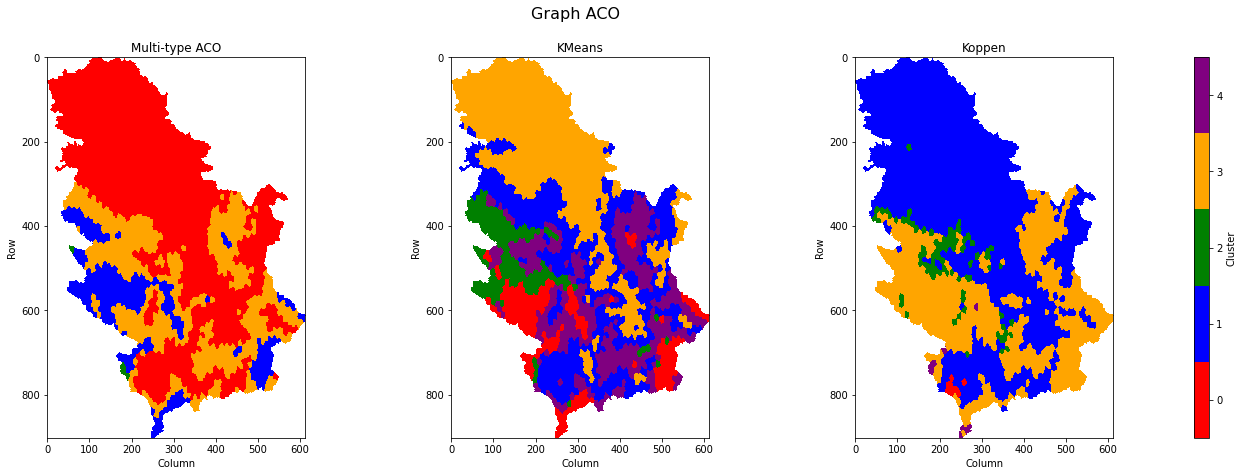

0.276120274343209
{'compactness': 0.29927425240383054, 'spatial': 0.2220943255350921}
ARI Multi-type ACO vs KMeans: 0.49091161584815257
ARI Koppen vs Multi-type ACO: 0.5638519381135996
0.44594638903049644


In [173]:
plot_cluster_comparison(
    df=df_model,
    label_dict={
        "Multi-type ACO": multi_type_aco.labels_,
        "KMeans": kmeans.labels_,
        "Koppen": koppen_labels["0"],
    },
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"Graph ACO",
)

multi_type_aco_centroid_fitness, multi_type_aco_centroid_terms = fitness_weighted_sum(
    X=X,
    labels=multi_type_aco.labels_,
    centroids=multi_type_aco.centroids_,
    weights=weights,
    neighbors=neighbors,
    **CENTROID_FITNESS_KWARGS,
    **COMMON_FITNESS_KWARGS,
)
print(multi_type_aco_centroid_fitness)
print(multi_type_aco_centroid_terms)
print("ARI Multi-type ACO vs KMeans:", adjusted_rand_score(multi_type_aco.labels_, kmeans.labels_))
print("ARI Koppen vs Multi-type ACO:", adjusted_rand_score(multi_type_aco.labels_, koppen_labels["0"]))

overall_multi_type_aco, per_cluster_multi_type_aco, merged_multi_type_aco = evaluate_label_set(
    method_name="Multi-type ACO",
    labels=multi_type_aco.labels_,
    data_df=df_model,
    node_col=node_col,
    vegetation=vegetation,
    legend=legend,
)

print(overall_multi_type_aco["weighted_combined_ecological_consistency"])

In [174]:
np.bincount(multi_type_aco.labels_)

array([1208,  238,    4,  559])

## Numerical comparison

ARI close to 1 means two labelings are very similar.

Fitness values are now comparable because both ACO variants use the same normalized weighted-sum fitness.


In [12]:
print("ACO best fitness:", aco.best_fitness_)
print("ACO + refinement best fitness:", aco_refinement.best_fitness_)
# print("graph_aco best fitness:", graph_aco.best_fitness_)
# print("graph_aco multi_type_aco fitness:", multi_type_aco.best_fitness_)
print()

print("ARI ACO vs KMeans:", adjusted_rand_score(aco.labels_, kmeans.labels_))
print("ARI ACO + refinement vs KMeans:", adjusted_rand_score(aco_refinement.labels_, kmeans.labels_))
# print("ARI multi_type_aco vs KMeans:", adjusted_rand_score(multi_type_aco.labels_, kmeans.labels_))
# print("ARI graph_aco vs KMeans:", adjusted_rand_score(graph_aco.labels_, kmeans.labels_))
print("ARI ACO vs ACO + refinement:", adjusted_rand_score(aco.labels_, aco_refinement.labels_))
print("ARI Koppen vs KMeans:", adjusted_rand_score(kmeans.labels_, koppen_labels["0"]))
print("ARI KMeans vs KMeans:", adjusted_rand_score(kmeans.labels_, kmeans.labels_))


# print("ARI graph_aco vs ACO + refinement:", adjusted_rand_score(graph_aco.labels_, aco_refinement.labels_))
# print("ARI graph_aco vs ACO:", adjusted_rand_score(aco.labels_, graph_aco.labels_))
# print("ARI multi_type_aco vs ACO + refinement:", adjusted_rand_score(multi_type_aco.labels_, aco_refinement.labels_))
# print("ARI multi_type_aco vs ACO:", adjusted_rand_score(aco.labels_, multi_type_aco.labels_))
# print("ARI multi_type_aco vs graph_aco:", adjusted_rand_score(multi_type_aco.labels_, graph_aco.labels_))
print()

aco_terms = pd.DataFrame(aco.term_history_)
aco_refinement_terms = pd.DataFrame(aco_refinement.term_history_)
# graph_aco_terms = pd.DataFrame(graph_aco.term_history_)
# multi_type_aco_terms = pd.DataFrame(multi_type_aco.term_history_)

display(aco_terms.tail())
display(aco_refinement_terms.tail())
# display(graph_aco_terms.tail())
# display(multi_type_aco_terms.tail())

ACO best fitness: 0.24128818400726199
ACO + refinement best fitness: 0.26319692899170816

ARI ACO vs KMeans: 0.8673115518109809
ARI ACO + refinement vs KMeans: 0.6718387549522244
ARI ACO vs ACO + refinement: 0.6283579634075822
ARI Koppen vs KMeans: 0.3975398254149832
ARI KMeans vs KMeans: 1.0



,iteration,iteration_best,global_best,mean,std,pheromone_min,pheromone_max,compactness,spatial
15,16,0.243409,0.243409,0.252219,0.010980,0.008387,0.966452,0.214719,0.310353
16,17,0.242107,0.242107,0.248839,0.007811,0.006822,0.972713,0.213125,0.309731
17,18,0.242400,0.242107,0.254266,0.018352,0.005550,0.977801,0.212677,0.311753
18,19,0.242121,0.242107,0.255164,0.020823,0.004514,0.981944,0.214092,0.307522
19,20,0.241288,0.241288,0.246557,0.007904,0.003669,0.985323,0.213129,0.306994


,iteration,iteration_best,global_best,mean,std,pheromone_min,pheromone_max,compactness,spatial
15,16,0.264674,0.264135,0.266173,0.001080,5.436320e-07,0.999998,0.237804,0.327371
16,17,0.264908,0.264135,0.265878,0.000551,5.434058e-07,0.999998,0.238272,0.327059
17,18,0.264395,0.264135,0.265868,0.000913,5.428944e-07,0.999998,0.237299,0.327619
18,19,0.264160,0.264135,0.265182,0.000816,5.427359e-07,0.999998,0.237163,0.327153
19,20,0.263197,0.263197,0.264569,0.001021,5.414939e-07,0.999998,0.236267,0.326033


In [28]:
koppen_labels["0"]

0       1
1       1
2       3
3       3
4       1
       ..
2004    1
2005    1
2006    3
2007    1
2008    2
Name: 0, Length: 2009, dtype: int64

## Plot ACO / ACO + refinement / KMeans side by side

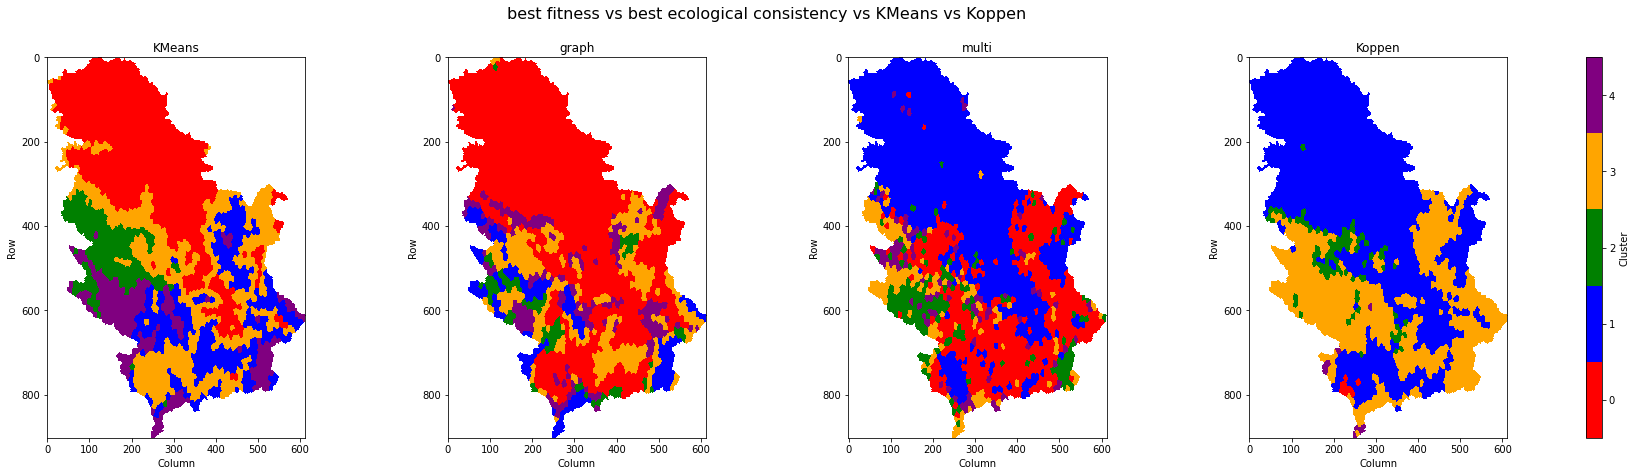

In [19]:
plot_cluster_comparison(
    df=df_model,
    label_dict={
        # "best fitness": aco.labels_,
        # "best ecological consistency": aco_refinement.labels_,
        "KMeans": kmeans.labels_,
        "graph": graph_aco.labels_,
        "multi": multi_type_aco.labels_,
        "Koppen": koppen_labels["0"],
    },
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"best fitness vs best ecological consistency vs KMeans vs Koppen",
    save_path="../../plot_comparison.png",
)


In [ ]:
import pandas as pd

from moduli.vegetation_eval import (
    load_clc_legend,
    attach_node_labels_to_pixels,
    merge_clusters_with_vegetation,
    add_clc_metadata,
    vegetation_quality_report,
    vegetation_contingency_table,
    plot_landcover_groups,
    plot_cluster_landcover,
)

In [ ]:
VEGETATION_PATH = "../vegetacija.csv"
CLC_LEGEND_PATH = "../Vegetacija/u2018_clc2018_v2020_20u1_raster100m/Legend/CLC2018_CLC2018_V2018_20_QGIS.txt"

vegetation = pd.read_csv(VEGETATION_PATH)
legend = load_clc_legend(CLC_LEGEND_PATH)

vegetation.head()

In [ ]:
method_labels = {
    "ACO": aco.labels_,
    "ACO + refinement": aco_refinement.labels_,
    "graph": graph_aco.labels_,
    "multi": multi_type_aco.labels_,
    "KMeans": kmeans.labels_,
}

vegetation_results = {}
vegetation_summaries = []

for method_name, labels in method_labels.items():
    df_clusters = attach_node_labels_to_pixels(
        df=df_model,
        node_labels=labels,
        node_col=node_col,
        cluster_col="cluster",
    )

    merged = merge_clusters_with_vegetation(
        clusters_df=df_clusters,
        vegetation_df=vegetation,
        cluster_col="cluster",
    )

    merged = add_clc_metadata(
        merged,
        legend=legend,
    )

    report = vegetation_quality_report(
        merged,
        cluster_col="cluster",
        class_col="clc_group",
    )

    vegetation_results[method_name] = {
        "merged": merged,
        "report": report,
    }

    summary = report["overall"].copy()
    summary["method"] = method_name
    vegetation_summaries.append(summary)

veg_comparison = pd.DataFrame(vegetation_summaries)

veg_comparison = veg_comparison[
    [
        "method",
        "weighted_dominant_class_share",
        "weighted_normalized_entropy",
        "weighted_simpson_diversity",
        "mean_dominant_class_share",
        "mean_normalized_entropy",
        "mean_simpson_diversity",
    ]
]

veg_comparison

## Optional: plot one result only

In [ ]:
plot_single_cluster_map(
    df=df_model,
    node_labels=aco_refinement.labels_,
    node_col=node_col,
    n_clusters=N_CLUSTERS,
    title=f"ACO + refinement via AntClusteringOptimizer ({MODE}, {FEATURE_MODE})",
)


## Optional: plot optimization histories

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(aco.history_, label="ACO")
plt.plot(aco_refinement.history_, label="ACO + refinement")
plt.xlabel("Iteration")
plt.ylabel("Global best fitness")
plt.title("Optimization history")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(aco_terms["compactness"], label="ACO compactness")
plt.plot(aco_refinement_terms["compactness"], label="ACO + refinement compactness")
plt.xlabel("Iteration")
plt.ylabel("Compactness")
plt.title("Compactness term")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(aco_terms["spatial"], label="ACO spatial")
plt.plot(aco_refinement_terms["spatial"], label="ACO + refinement spatial")
plt.xlabel("Iteration")
plt.ylabel("Spatial disagreement")
plt.title("Spatial term")
plt.legend()
plt.grid(True)
plt.show()


## Optional: PCA after superpixelization

This matches your older PCA workflow more closely.

Run this section instead of the earlier feature/preprocessing cells if you want:
raw features → superpixels → PCA → optimizer.


In [ ]:
# Example only. Do not run unless you want PCA after superpixelization.

# from preprocessing import replace_model_features
#
# raw_X, feature_cols = build_raw_features(df)
#
# data_raw = prepare_model_data(
#     df=df,
#     X_features=raw_X,
#     feature_names=feature_cols,
#     mode=MODE,
#     target_size=TARGET_SIZE,
#     k_neighbors=K_NEIGHBORS,
#     scale_final=False,
#     random_state=RANDOM_STATE,
# )
#
# X_super_df = pd.DataFrame(
#     data_raw["X_model_unscaled"],
#     columns=feature_cols,
# )
#
# temp_cols = [c for c in feature_cols if "temp" in c.lower()]
# rain_cols = [c for c in feature_cols if "padavine" in c.lower()]
#
# X_pca, pca_names, pca_info = build_temp_rain_pca_features(
#     X_super_df,
#     temp_cols=temp_cols,
#     rain_cols=rain_cols,
#     n_temp=2,
#     n_rain=2,
#     final_scale=True,
# )
#
# data = replace_model_features(data_raw, X_pca, pca_names)
#
# X = data["X_model"]
# neighbors = data["neighbors"]
# weights = data["weights"]
# df_model = data["df"]
# node_col = data["node_col"]
